# Value and Momentum on MOEX

Replication of Asness, Moskowitz, and Pedersen (2013) "Value and Momentum Everywhere" on Russian equities (MOEX, 2022–2026). Tests both a return-based value proxy (paper shows r=0.86 with book-to-market) and real P/B fundamentals from Tinkoff Invest API. Momentum is the standard 12-1 month return. The study covers: value and momentum in isolation, their cross-sectional correlation, the 50/50 combination strategy, double 3×3 independent sort, and a current portfolio recommendation based on live P/B data from Tinkoff.

In [50]:
# Imports and parameters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from data_cache import get_stocks, get_index, RU_UNIVERSE_100, MOEX_INDEX

# Transaction costs (Trader tariff)
COMMISSION_PCT = 0.0005
SLIPPAGE_PCT = 0.0008
TOTAL_COST_PCT = (COMMISSION_PCT + SLIPPAGE_PCT) * 2  # ~0.26% round-trip

START_DATE = "2022-01-01"

In [51]:
# Load daily stock data and IMOEX index
print("=== Daily candles: 100 stocks ===")
stocks_d = get_stocks(RU_UNIVERSE_100, interval=24, start=START_DATE, verbose=True)
print(f"\nTotal: {len(stocks_d)} daily candles, {stocks_d['ticker'].nunique()} tickers")
print(f"Period: {stocks_d['timestamp'].min().date()} - {stocks_d['timestamp'].max().date()}")

# IMOEX as benchmark
imoex = get_index(MOEX_INDEX, interval=24, start=START_DATE)
print(f"IMOEX: {len(imoex)} candles")

=== Daily candles: 100 stocks ===
  SBER: из кэша (1213 свечей)
  SBERP: из кэша (1213 свечей)
  GAZP: из кэша (1213 свечей)
  LKOH: из кэша (1213 свечей)
  ROSN: из кэша (1213 свечей)
  NVTK: из кэша (1209 свечей)
  GMKN: из кэша (1209 свечей)
  MGNT: из кэша (1213 свечей)
  MOEX: из кэша (1213 свечей)
  VTBR: из кэша (1209 свечей)
  TATN: из кэша (1211 свечей)
  PLZL: из кэша (1206 свечей)
  CHMF: из кэша (1213 свечей)
  NLMK: из кэша (1213 свечей)
  MTSS: из кэша (1212 свечей)
  SNGS: из кэша (1213 свечей)
  AFLT: из кэша (1213 свечей)
  ALRS: из кэша (1213 свечей)
  PHOR: из кэша (1211 свечей)
  RUAL: из кэша (1213 свечей)
  TATNP: из кэша (1211 свечей)
  SNGSP: из кэша (1213 свечей)
  BANE: из кэша (1205 свечей)
  BANEP: из кэша (1205 свечей)
  RNFT: из кэша (1207 свечей)
  TRNFP: из кэша (1209 свечей)
  BSPB: из кэша (1207 свечей)
  CBOM: из кэша (1213 свечей)
  SVCB: из кэша (736 свечей)
  T: из кэша (1183 свечей)
  RENI: из кэша (1207 свечей)
  SFIN: из кэша (1205 свечей)
  SPB

In [52]:
# Prepare monthly prices and returns
stocks_d["date"] = stocks_d["timestamp"].dt.date
prices = stocks_d.pivot_table(index="date", columns="ticker", values="close", aggfunc="last")
prices.index = pd.to_datetime(prices.index)

monthly_prices = prices.resample("ME").last()
monthly_ret = monthly_prices.pct_change()

# IMOEX monthly returns (benchmark)
imoex["date"] = imoex["timestamp"].dt.date
imoex_prices = imoex.set_index("date")["close"]
imoex_prices.index = pd.to_datetime(imoex_prices.index)
imoex_monthly = imoex_prices.resample("ME").last().pct_change()

print(f"Monthly periods: {len(monthly_ret)}")
print(f"Tickers: {monthly_ret.shape[1]}")
print(f"Each month has ~{monthly_ret.count(axis=1).mean():.0f} tickers")

Monthly periods: 54
Tickers: 109
Each month has ~102 tickers


In [53]:
# Construct value and momentum signals

def momentum_signal(monthly_prices, lookback=12, skip=1):
    """MOM2-12: cumulative return from t-lookback to t-skip."""
    p_recent = monthly_prices.shift(skip)
    p_old = monthly_prices.shift(lookback)
    return (p_recent / p_old) - 1


def value_signal(monthly_prices, lookback=36):
    """Value proxy: negative of past long-term return (Asness et al. show r=0.86 with BE/ME)."""
    p_old = monthly_prices.shift(lookback)
    p_now = monthly_prices
    long_term_ret = (p_now / p_old) - 1
    return -long_term_ret  # negative = cheap stocks score high


# Primary signals
mom_12_1 = momentum_signal(monthly_prices, lookback=12, skip=1)
val_36 = value_signal(monthly_prices, lookback=36)

# Alternative value lookbacks for robustness
val_24 = value_signal(monthly_prices, lookback=24)
val_48 = value_signal(monthly_prices, lookback=48)

# Signal coverage
for name, sig in [("MOM 12-1", mom_12_1), ("VAL 36m", val_36),
                   ("VAL 24m", val_24), ("VAL 48m", val_48)]:
    valid = sig.dropna(how="all")
    print(f"{name}: {len(valid)} months with signals, "
          f"~{valid.count(axis=1).mean():.0f} stocks/month")

MOM 12-1: 42 months with signals, ~102 stocks/month
VAL 36m: 18 months with signals, ~96 stocks/month
VAL 24m: 30 months with signals, ~99 stocks/month
VAL 48m: 6 months with signals, ~94 stocks/month


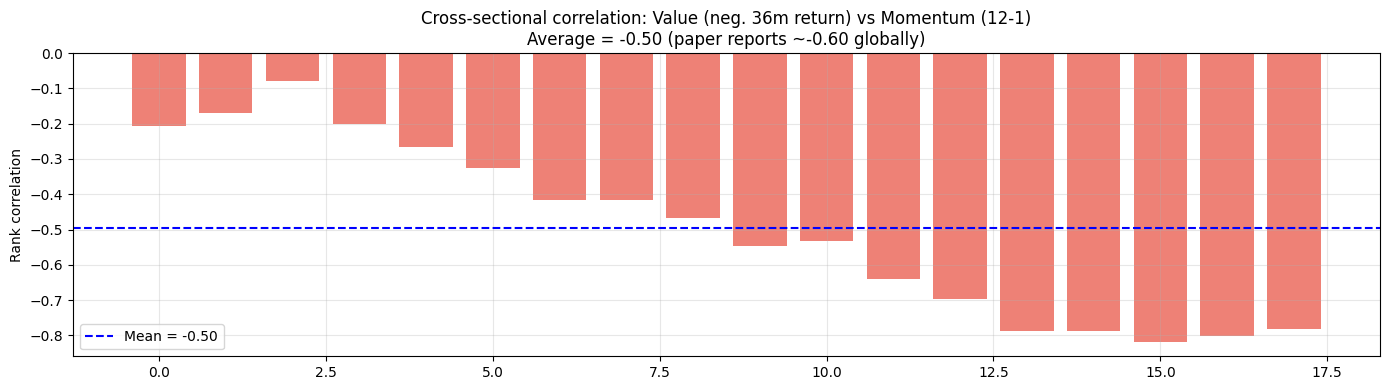

Mean correlation: -0.497
Months with negative correlation: 18/18


In [54]:
# Cross-sectional correlation between value and momentum signals
# Paper finds ~-0.60 average correlation across markets

monthly_corrs = []
common_dates = val_36.dropna(how="all").index.intersection(mom_12_1.dropna(how="all").index)

for date in common_dates:
    v = val_36.loc[date].dropna()
    m = mom_12_1.loc[date].dropna()
    common = v.index.intersection(m.index)
    if len(common) >= 20:
        corr = v[common].corr(m[common])
        monthly_corrs.append({"date": date, "corr": corr})

corr_df = pd.DataFrame(monthly_corrs).set_index("date")
avg_corr = corr_df["corr"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(corr_df)), corr_df["corr"],
       color=["#e74c3c" if c < 0 else "#2ecc71" for c in corr_df["corr"]], alpha=0.7)
ax.axhline(avg_corr, color="blue", linestyle="--",
           label=f"Mean = {avg_corr:.2f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"Cross-sectional correlation: Value (neg. 36m return) vs Momentum (12-1)\n"
             f"Average = {avg_corr:.2f} (paper reports ~-0.60 globally)")
ax.set_ylabel("Rank correlation")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean correlation: {avg_corr:.3f}")
print(f"Months with negative correlation: {(corr_df['corr'] < 0).sum()}/{len(corr_df)}")

In [55]:
# Tercile portfolio sorts (following paper: P1=low, P2=mid, P3=high)

def tercile_sort(signal_df, returns_df, min_stocks=20):
    """Sort stocks into terciles by signal, return equal-weight portfolio returns."""
    rows = []
    for date in signal_df.index:
        sig = signal_df.loc[date].dropna()
        if len(sig) < min_stocks:
            continue
        try:
            next_idx = returns_df.index.get_loc(date) + 1
            if next_idx >= len(returns_df):
                continue
            next_date = returns_df.index[next_idx]
        except KeyError:
            continue
        next_rets = returns_df.loc[next_date].dropna()
        common = sig.index.intersection(next_rets.index)
        if len(common) < min_stocks:
            continue
        sig_c = sig[common]
        ret_c = next_rets[common]
        try:
            q = pd.qcut(sig_c, 3, labels=["P1", "P2", "P3"], duplicates="drop")
        except ValueError:
            continue
        row = {"date": next_date}
        for p in ["P1", "P2", "P3"]:
            mask = (q == p)
            if mask.sum() > 0:
                row[p] = ret_c[mask].mean()
        rows.append(row)
    df = pd.DataFrame(rows).set_index("date")
    if "P3" in df.columns and "P1" in df.columns:
        df["P3-P1"] = df["P3"] - df["P1"]
    return df


# Value terciles
val_terciles = tercile_sort(val_36, monthly_ret)
# Momentum terciles
mom_terciles = tercile_sort(mom_12_1, monthly_ret)

print(f"Value terciles: {len(val_terciles)} months")
print(f"Momentum terciles: {len(mom_terciles)} months")

Value terciles: 17 months
Momentum terciles: 41 months


In [56]:
# Signal-weighted factor portfolios (paper eq. 1-3)
# w_i = c * (rank(S_i) - mean(rank(S_i))/N), dollar-neutral

def signal_weighted_factor(signal_df, returns_df, min_stocks=20,
                            cost_per_rebalance=TOTAL_COST_PCT):
    """Rank-weighted long-short factor portfolio."""
    monthly_rets = {}
    for date in signal_df.index:
        sig = signal_df.loc[date].dropna()
        if len(sig) < min_stocks:
            continue
        try:
            next_idx = returns_df.index.get_loc(date) + 1
            if next_idx >= len(returns_df):
                continue
            next_date = returns_df.index[next_idx]
        except KeyError:
            continue
        next_rets = returns_df.loc[next_date].dropna()
        common = sig.index.intersection(next_rets.index)
        if len(common) < min_stocks:
            continue
        sig_c = sig[common]
        ret_c = next_rets[common]
        # Rank-based weights (eq. 1)
        ranks = sig_c.rank()
        weights = ranks - ranks.mean()
        # Scale to $1 long, $1 short
        pos_sum = weights[weights > 0].sum()
        neg_sum = weights[weights < 0].abs().sum()
        if pos_sum == 0 or neg_sum == 0:
            continue
        weights = weights / max(pos_sum, neg_sum)
        factor_ret = (weights * ret_c).sum() - cost_per_rebalance
        monthly_rets[next_date] = factor_ret
    return pd.Series(monthly_rets).sort_index()


val_factor = signal_weighted_factor(val_36, monthly_ret)
mom_factor = signal_weighted_factor(mom_12_1, monthly_ret)
# 50/50 combination (paper eq. 3)
common_idx = val_factor.index.intersection(mom_factor.index)
combo_factor = 0.5 * val_factor[common_idx] + 0.5 * mom_factor[common_idx]

print(f"Value factor: {len(val_factor)} months")
print(f"Momentum factor: {len(mom_factor)} months")
print(f"Combination factor: {len(combo_factor)} months")

Value factor: 17 months
Momentum factor: 41 months
Combination factor: 17 months


In [57]:
# Performance metrics

def compute_metrics(returns, benchmark=None, label=""):
    """Annualized metrics from monthly returns."""
    r = returns.dropna()
    if len(r) < 6:
        return None
    n = len(r)
    mean_m = r.mean()
    std_m = r.std(ddof=1)
    ann_ret = (1 + mean_m) ** 12 - 1
    ann_vol = std_m * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    t_stat = mean_m / (std_m / np.sqrt(n))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))
    cum = (1 + r).cumprod()
    max_dd = ((cum.cummax() - cum) / cum.cummax()).max()
    
    result = {
        "label": label, "n_months": n,
        "ann_ret_%": ann_ret * 100,
        "ann_vol_%": ann_vol * 100,
        "sharpe": sharpe,
        "t_stat": t_stat,
        "p_value": p_value,
        "max_dd_%": max_dd * 100,
        "win_rate_%": (r > 0).mean() * 100,
    }
    if benchmark is not None:
        b = benchmark.reindex(r.index).dropna()
        common = r.index.intersection(b.index)
        alpha = r[common] - b[common]
        if len(alpha) > 6:
            t_a, p_a = stats.ttest_1samp(alpha, 0)
            result["alpha_ann_%"] = ((1 + alpha.mean()) ** 12 - 1) * 100
            result["alpha_t"] = t_a
            result["alpha_p"] = p_a
    return result

In [58]:
# Table I replication: tercile portfolio performance

def print_table(terciles, name, benchmark=None):
    print(f"\n{'='*70}")
    print(f"  {name}: Tercile Portfolio Performance")
    print(f"{'='*70}")
    rows = []
    for col in ["P1", "P2", "P3", "P3-P1"]:
        if col not in terciles.columns:
            continue
        m = compute_metrics(terciles[col] - TOTAL_COST_PCT / 2 if col != "P3-P1"
                            else terciles[col] - TOTAL_COST_PCT,
                            benchmark=benchmark, label=col)
        if m:
            rows.append(m)
    df = pd.DataFrame(rows).set_index("label")
    display(df.round(3))
    return df


val_table = print_table(val_terciles, "VALUE (negative 36m return)", imoex_monthly)
mom_table = print_table(mom_terciles, "MOMENTUM (12-1)", imoex_monthly)


  VALUE (negative 36m return): Tercile Portfolio Performance


,n_months,ann_ret_%,ann_vol_%,sharpe,t_stat,p_value,max_dd_%,win_rate_%,alpha_ann_%,alpha_t,alpha_p
label,,,,,,,,,,,
P1,17,1.257,17.452,0.072,0.085,0.933,16.273,35.294,11.378,1.638,0.121
P2,17,-16.976,17.164,-0.989,-1.280,0.219,28.630,35.294,-8.533,-1.433,0.171
P3,17,-18.336,22.703,-0.808,-1.053,0.308,35.949,35.294,-10.020,-1.162,0.262
P3-P1,17,-21.892,12.511,-1.750,-2.327,0.033,35.449,17.647,-13.907,-1.108,0.284



  MOMENTUM (12-1): Tercile Portfolio Performance


,n_months,ann_ret_%,ann_vol_%,sharpe,t_stat,p_value,max_dd_%,win_rate_%,alpha_ann_%,alpha_t,alpha_p
label,,,,,,,,,,,
P1,41,-7.129,24.733,-0.288,-0.551,0.585,53.368,48.780,-12.130,-2.169,0.036
P2,41,15.159,24.346,0.623,1.078,0.288,29.747,51.220,9.066,1.529,0.134
P3,41,15.593,28.664,0.544,0.940,0.353,42.257,51.220,9.478,1.006,0.320
P3-P1,41,20.545,14.397,1.427,2.418,0.020,16.830,58.537,14.190,1.088,0.283


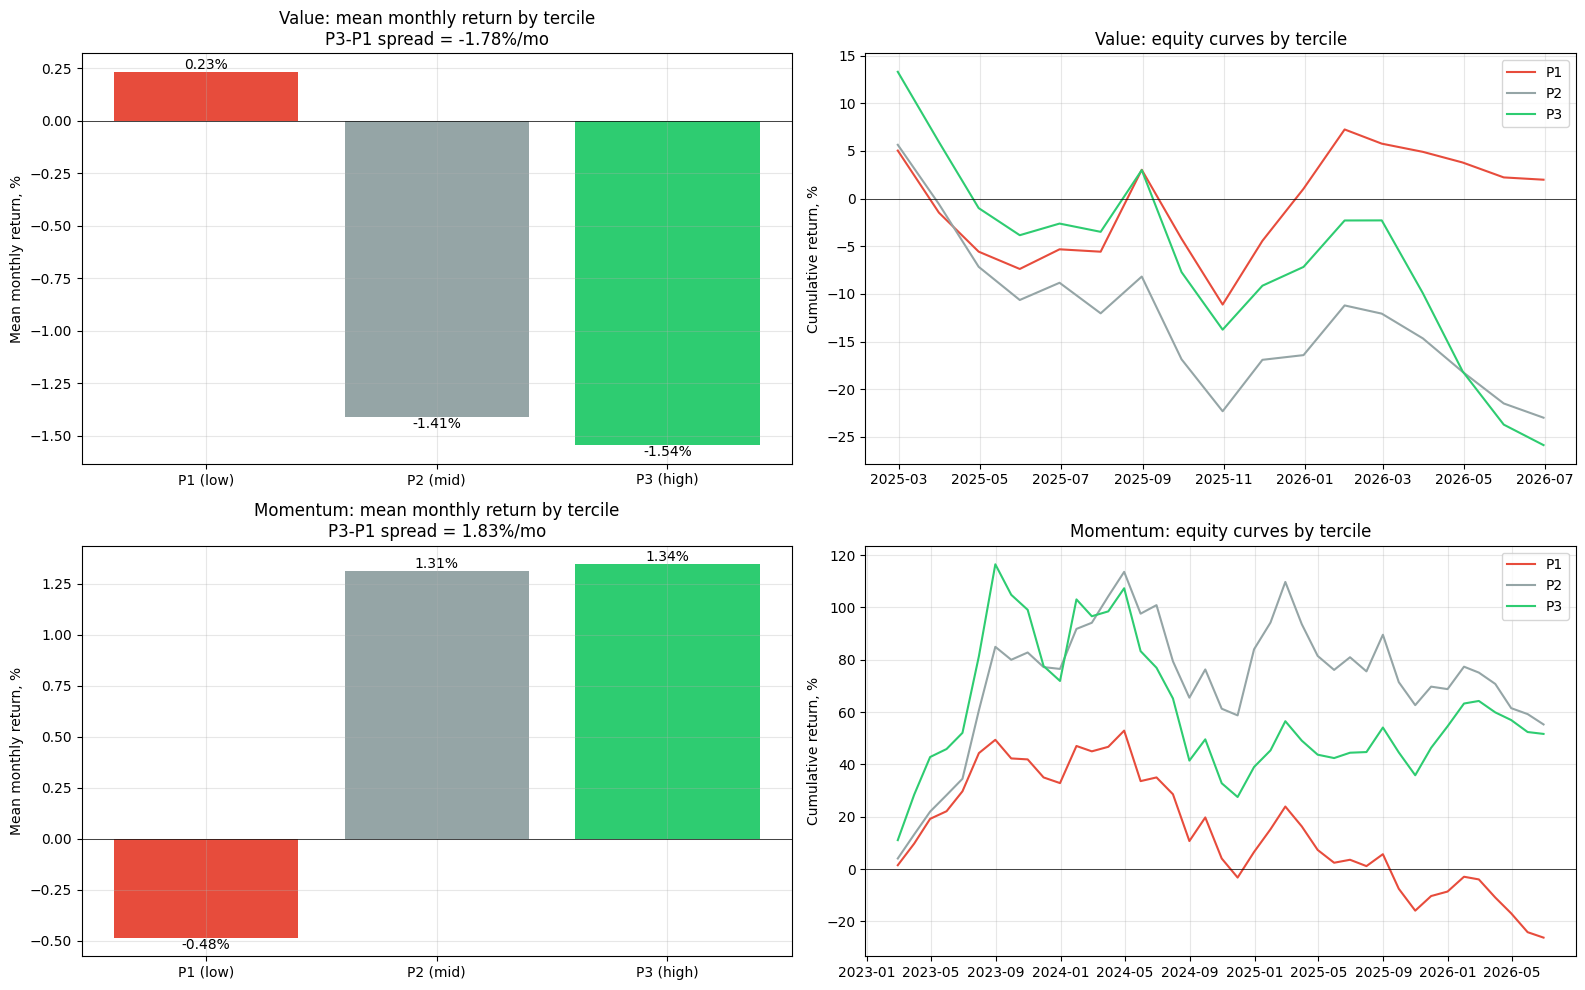

In [59]:
# Tercile return visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_t = ["#e74c3c", "#95a5a6", "#2ecc71"]

# Value: bar chart
for ax, terciles, name in [(axes[0, 0], val_terciles, "Value"),
                            (axes[1, 0], mom_terciles, "Momentum")]:
    means = [terciles[p].mean() * 100 for p in ["P1", "P2", "P3"]]
    bars = ax.bar(["P1 (low)", "P2 (mid)", "P3 (high)"], means, color=colors_t)
    ax.axhline(0, color="black", linewidth=0.5)
    spread = terciles["P3-P1"].mean() * 100
    ax.set_title(f"{name}: mean monthly return by tercile\n"
                 f"P3-P1 spread = {spread:.2f}%/mo")
    ax.set_ylabel("Mean monthly return, %")
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, val,
                f"{val:.2f}%", ha="center",
                va="bottom" if val >= 0 else "top", fontsize=10)

# Value: equity curves
for ax, terciles, name in [(axes[0, 1], val_terciles, "Value"),
                            (axes[1, 1], mom_terciles, "Momentum")]:
    for i, p in enumerate(["P1", "P2", "P3"]):
        cum = (1 + terciles[p]).cumprod() * 100 - 100
        ax.plot(cum.index, cum, label=p, color=colors_t[i], linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{name}: equity curves by tercile")
    ax.set_ylabel("Cumulative return, %")
    ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# Factor portfolio comparison: Value vs Momentum vs 50/50 Combination

results = []
for name, factor in [("Value", val_factor), ("Momentum", mom_factor),
                      ("50/50 Combo", combo_factor)]:
    m = compute_metrics(factor, label=name)
    if m:
        results.append(m)

factor_df = pd.DataFrame(results).set_index("label")
print("Signal-weighted factor portfolios (rank-based, dollar-neutral):")
display(factor_df.round(3))

# Factor return correlation
factor_corr = val_factor[common_idx].corr(mom_factor[common_idx])
print(f"\nValue-Momentum factor return correlation: {factor_corr:.3f}")
print(f"(Paper reports ~-0.60 across markets)")

Signal-weighted factor portfolios (rank-based, dollar-neutral):


,n_months,ann_ret_%,ann_vol_%,sharpe,t_stat,p_value,max_dd_%,win_rate_%
label,,,,,,,,
Value,17,-21.034,13.895,-1.514,-2.003,0.062,35.845,17.647
Momentum,41,20.558,14.886,1.381,2.340,0.024,19.338,60.976
50/50 Combo,17,4.197,5.737,0.732,0.854,0.405,3.667,58.824



Value-Momentum factor return correlation: -0.564
(Paper reports ~-0.60 across markets)


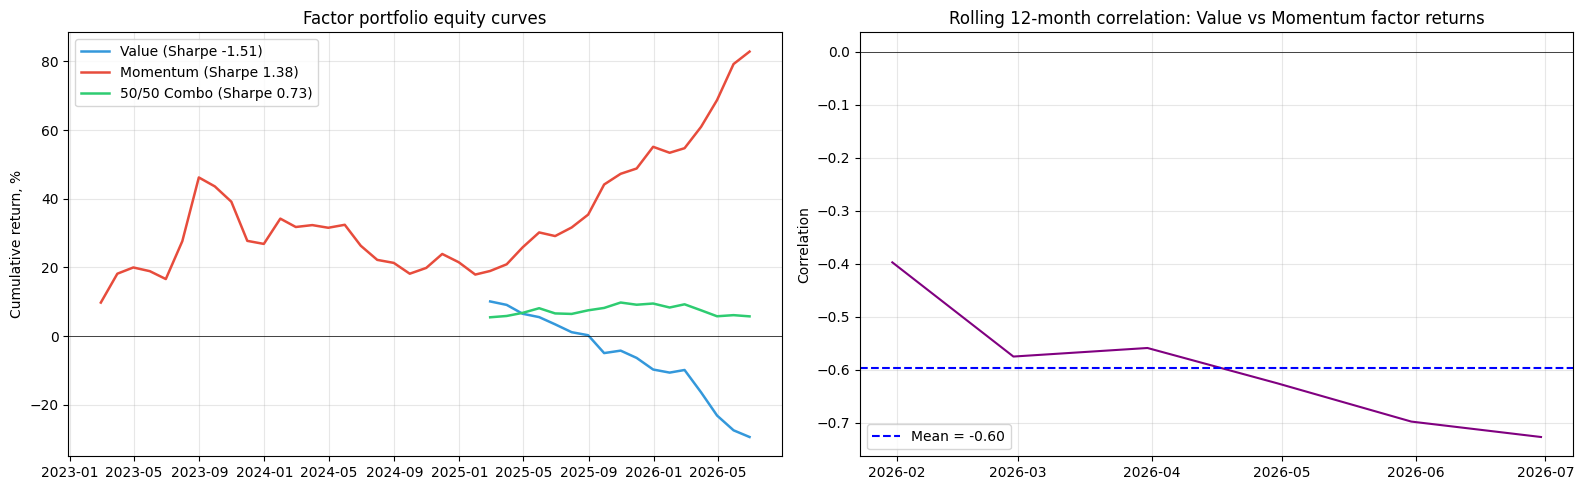

In [61]:
# Factor equity curves

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Equity curves
for name, factor, color in [("Value", val_factor, "#3498db"),
                             ("Momentum", mom_factor, "#e74c3c"),
                             ("50/50 Combo", combo_factor, "#2ecc71")]:
    cum = (1 + factor).cumprod() * 100 - 100
    m = compute_metrics(factor)
    axes[0].plot(cum.index, cum, color=color, linewidth=1.8,
                label=f"{name} (Sharpe {m['sharpe']:.2f})")

axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Factor portfolio equity curves")
axes[0].set_ylabel("Cumulative return, %")
axes[0].legend()

# Rolling 12m correlation
rolling_corr = val_factor[common_idx].rolling(12).corr(mom_factor[common_idx])
axes[1].plot(rolling_corr.index, rolling_corr, color="purple", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axhline(rolling_corr.mean(), color="blue", linestyle="--",
                label=f"Mean = {rolling_corr.mean():.2f}")
axes[1].set_title("Rolling 12-month correlation: Value vs Momentum factor returns")
axes[1].set_ylabel("Correlation")
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
# Practical long-only combination strategy
# Rank stocks by combined z-score: 50% value + 50% momentum

def combined_signal_backtest(val_sig, mom_sig, returns_df,
                              val_weight=0.5, top_pct=0.20,
                              min_stocks=20, cost=TOTAL_COST_PCT):
    """Long-only portfolio based on combined value+momentum z-score rank."""
    monthly_rets = {}
    holdings_log = {}
    
    for date in val_sig.index:
        v = val_sig.loc[date].dropna()
        m = mom_sig.loc[date].dropna()
        common = v.index.intersection(m.index)
        if len(common) < min_stocks:
            continue
        try:
            next_idx = returns_df.index.get_loc(date) + 1
            if next_idx >= len(returns_df):
                continue
            next_date = returns_df.index[next_idx]
        except KeyError:
            continue
        next_rets = returns_df.loc[next_date].dropna()
        common = common.intersection(next_rets.index)
        if len(common) < min_stocks:
            continue
        # Cross-sectional z-scores
        v_z = (v[common].rank(pct=True) - 0.5)  # centered percentile rank
        m_z = (m[common].rank(pct=True) - 0.5)
        combo = val_weight * v_z + (1 - val_weight) * m_z
        # Select top stocks
        n_pick = max(1, int(len(common) * top_pct))
        picks = combo.nlargest(n_pick).index
        port_ret = next_rets[picks].mean() - cost
        monthly_rets[next_date] = port_ret
        holdings_log[next_date] = list(picks)
    
    return pd.Series(monthly_rets).sort_index(), holdings_log


# Grid: different value weights and portfolio sizes
grid_results = []
for val_w in [0.0, 0.25, 0.50, 0.75, 1.0]:
    for top_p in [0.10, 0.20, 0.30]:
        rets, _ = combined_signal_backtest(val_36, mom_12_1, monthly_ret,
                                            val_weight=val_w, top_pct=top_p)
        m = compute_metrics(rets, benchmark=imoex_monthly,
                            label=f"V={int(val_w*100)}% top-{int(top_p*100)}%")
        if m:
            m["val_weight"] = val_w
            m["top_pct"] = top_p
            grid_results.append(m)

grid_df = pd.DataFrame(grid_results)
print("Long-only combined strategy: value weight x portfolio size")
display(grid_df[["label", "n_months", "ann_ret_%", "sharpe", "t_stat",
                  "p_value", "max_dd_%", "win_rate_%"]]
        .sort_values("sharpe", ascending=False).round(3))

Long-only combined strategy: value weight x portfolio size


,label,n_months,ann_ret_%,sharpe,t_stat,p_value,max_dd_%,win_rate_%
0,V=0% top-10%,17,24.870,1.003,1.076,0.298,14.216,58.824
3,V=25% top-10%,17,12.471,0.518,0.583,0.568,16.323,41.176
1,V=0% top-20%,17,8.998,0.504,0.577,0.572,12.265,52.941
2,V=0% top-30%,17,5.228,0.314,0.365,0.720,12.366,47.059
4,V=25% top-20%,17,5.988,0.299,0.347,0.733,13.822,52.941
5,V=25% top-30%,17,3.371,0.181,0.213,0.834,15.124,41.176
6,V=50% top-10%,17,-8.913,-0.332,-0.412,0.686,31.042,35.294
7,V=50% top-20%,17,-10.585,-0.491,-0.615,0.547,27.688,41.176
8,V=50% top-30%,17,-10.781,-0.531,-0.665,0.515,26.484,41.176
9,V=75% top-10%,17,-18.336,-0.568,-0.741,0.470,44.125,35.294


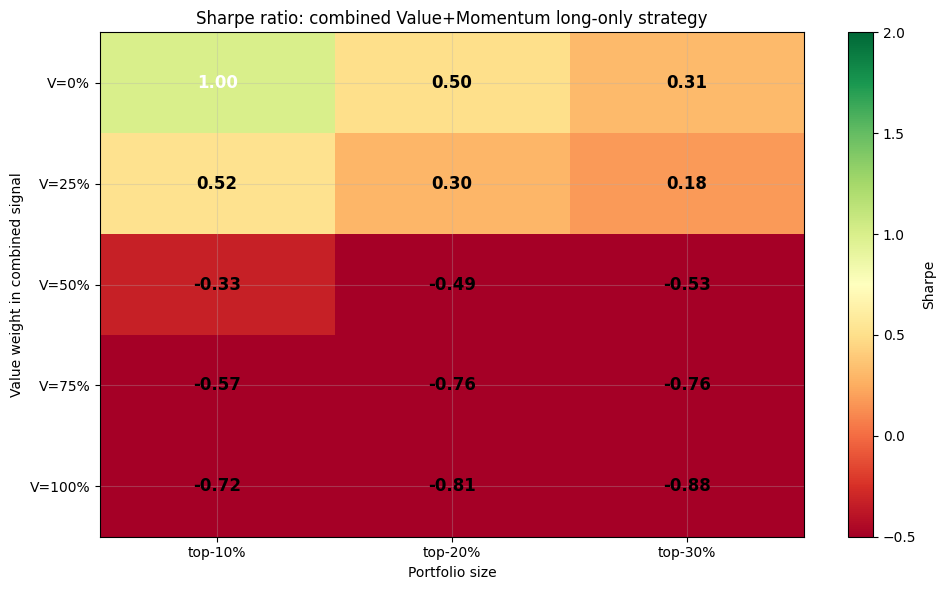

In [63]:
# Sharpe heatmap: value weight vs portfolio size

fig, ax = plt.subplots(figsize=(10, 6))
pivot = grid_df.pivot(index="val_weight", columns="top_pct", values="sharpe")
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-0.5, vmax=2.0)
plt.colorbar(im, ax=ax, label="Sharpe")

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f"top-{int(c*100)}%" for c in pivot.columns])
ax.set_yticklabels([f"V={int(v*100)}%" for v in pivot.index])
ax.set_xlabel("Portfolio size")
ax.set_ylabel("Value weight in combined signal")
ax.set_title("Sharpe ratio: combined Value+Momentum long-only strategy")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if abs(val) > 1 else "black")

plt.tight_layout()
plt.show()

Best config: value weight = 0%, top = 10%


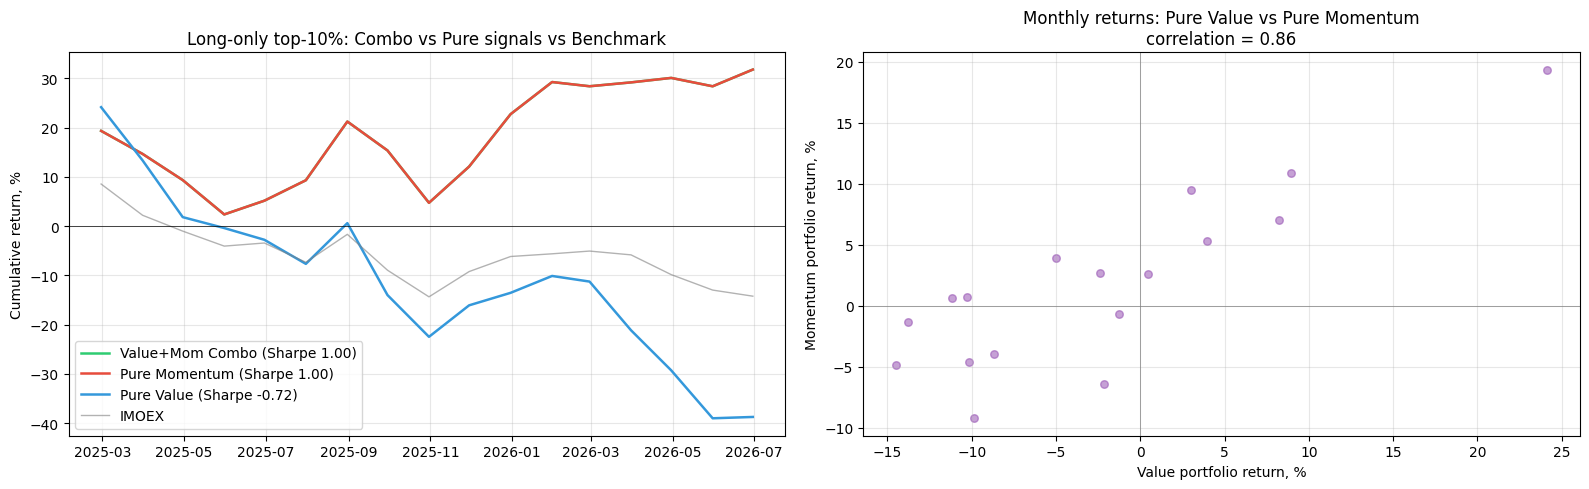

In [64]:
# Best combination vs pure value, pure momentum, and benchmark

best = grid_df.sort_values("sharpe", ascending=False).iloc[0]
best_vw = best["val_weight"]
best_tp = best["top_pct"]
print(f"Best config: value weight = {best_vw:.0%}, top = {best_tp:.0%}")

combo_rets, combo_holdings = combined_signal_backtest(
    val_36, mom_12_1, monthly_ret, val_weight=best_vw, top_pct=best_tp)
pure_val_rets, _ = combined_signal_backtest(
    val_36, mom_12_1, monthly_ret, val_weight=1.0, top_pct=best_tp)
pure_mom_rets, _ = combined_signal_backtest(
    val_36, mom_12_1, monthly_ret, val_weight=0.0, top_pct=best_tp)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Equity curves
bench_common = imoex_monthly.reindex(combo_rets.index).dropna()
for name, r, color in [("Value+Mom Combo", combo_rets, "#2ecc71"),
                        ("Pure Momentum", pure_mom_rets, "#e74c3c"),
                        ("Pure Value", pure_val_rets, "#3498db")]:
    cum = (1 + r).cumprod() * 100 - 100
    m = compute_metrics(r)
    axes[0].plot(cum.index, cum, color=color, linewidth=1.8,
                label=f"{name} (Sharpe {m['sharpe']:.2f})")

cum_bench = (1 + bench_common).cumprod() * 100 - 100
axes[0].plot(cum_bench.index, cum_bench, color="grey", linewidth=1, alpha=0.6,
            label="IMOEX")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title(f"Long-only top-{int(best_tp*100)}%: Combo vs Pure signals vs Benchmark")
axes[0].set_ylabel("Cumulative return, %")
axes[0].legend()

# Monthly returns comparison
axes[1].scatter(pure_val_rets * 100, pure_mom_rets * 100, alpha=0.5, s=30, color="#8e44ad")
corr_lo = pure_val_rets.corr(pure_mom_rets)
axes[1].set_title(f"Monthly returns: Pure Value vs Pure Momentum\ncorrelation = {corr_lo:.2f}")
axes[1].set_xlabel("Value portfolio return, %")
axes[1].set_ylabel("Momentum portfolio return, %")
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].axvline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.show()

In [65]:
# Robustness: different value lookback periods
# Paper uses 5-year (60m), but our data starts 2022 so we test 24, 36, 48 months

rob_results = []
for lb, val_sig in [(24, val_24), (36, val_36), (48, val_48)]:
    for val_w in [0.0, 0.50, 1.0]:
        rets, _ = combined_signal_backtest(val_sig, mom_12_1, monthly_ret,
                                            val_weight=val_w, top_pct=0.20)
        m = compute_metrics(rets, benchmark=imoex_monthly,
                            label=f"VAL-{lb}m V={int(val_w*100)}%")
        if m:
            m["val_lookback"] = lb
            m["val_weight"] = val_w
            rob_results.append(m)

rob_df = pd.DataFrame(rob_results)
print("Robustness: value lookback period x value weight (top-20%)")
display(rob_df[["label", "n_months", "ann_ret_%", "sharpe", "t_stat",
                 "p_value", "max_dd_%"]]
        .sort_values("sharpe", ascending=False).round(3))

Robustness: value lookback period x value weight (top-20%)


,label,n_months,ann_ret_%,sharpe,t_stat,p_value,max_dd_%
3,VAL-36m V=0%,17,8.998,0.504,0.577,0.572,12.265
0,VAL-24m V=0%,29,-7.773,-0.357,-0.576,0.570,37.469
4,VAL-36m V=50%,17,-10.585,-0.491,-0.615,0.547,27.688
1,VAL-24m V=50%,29,-12.027,-0.509,-0.838,0.409,35.047
2,VAL-24m V=100%,29,-21.824,-0.790,-1.371,0.181,48.628
5,VAL-36m V=100%,17,-22.485,-0.814,-1.086,0.294,43.957


In [66]:
# Robustness: momentum lookback variants combined with value

mom_variants = [
    ("MOM 12-1", momentum_signal(monthly_prices, 12, 1)),
    ("MOM 6-1", momentum_signal(monthly_prices, 6, 1)),
    ("MOM 3-1", momentum_signal(monthly_prices, 3, 1)),
    ("MOM 12-0", momentum_signal(monthly_prices, 12, 0)),
]

mom_rob = []
for mom_name, mom_sig in mom_variants:
    for val_w in [0.0, 0.50]:
        rets, _ = combined_signal_backtest(val_36, mom_sig, monthly_ret,
                                            val_weight=val_w, top_pct=0.20)
        label = f"{mom_name} V={int(val_w*100)}%"
        m = compute_metrics(rets, benchmark=imoex_monthly, label=label)
        if m:
            mom_rob.append(m)

mom_rob_df = pd.DataFrame(mom_rob)
print("Robustness: momentum variant x value inclusion (top-20%)")
display(mom_rob_df[["label", "n_months", "ann_ret_%", "sharpe", "t_stat",
                     "p_value", "max_dd_%"]]
        .sort_values("sharpe", ascending=False).round(3))

Robustness: momentum variant x value inclusion (top-20%)


,label,n_months,ann_ret_%,sharpe,t_stat,p_value,max_dd_%
6,MOM 12-0 V=0%,17,9.411,0.520,0.594,0.561,12.135
0,MOM 12-1 V=0%,17,8.998,0.504,0.577,0.572,12.265
2,MOM 6-1 V=0%,17,-1.977,-0.111,-0.133,0.896,18.343
7,MOM 12-0 V=50%,17,-7.579,-0.361,-0.445,0.662,24.083
1,MOM 12-1 V=50%,17,-10.585,-0.491,-0.615,0.547,27.688
4,MOM 3-1 V=0%,17,-8.940,-0.507,-0.629,0.538,21.475
3,MOM 6-1 V=50%,17,-18.622,-0.808,-1.056,0.307,37.202
5,MOM 3-1 V=50%,17,-23.127,-0.955,-1.279,0.219,43.137


Double sort: 17 months



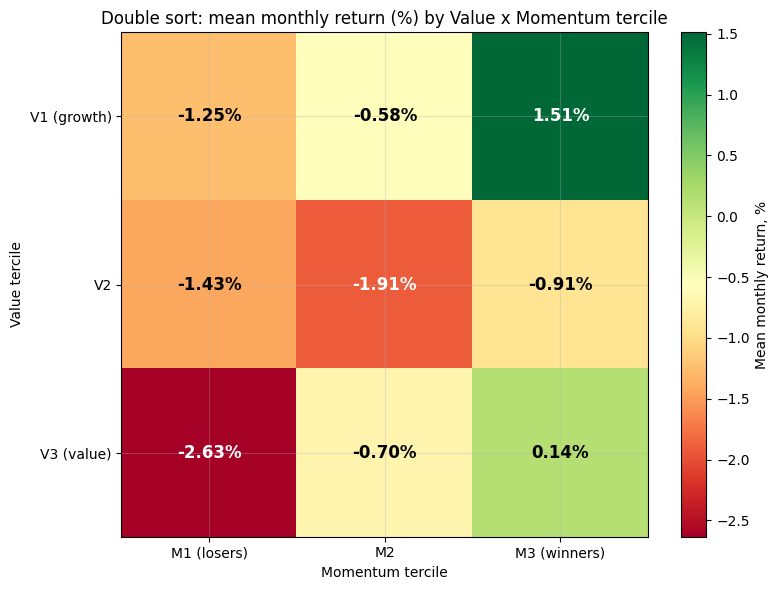

Value effect (V3-V1) within each momentum tercile:
  M1: V3-V1 = -1.39%/mo
  M2: V3-V1 = -0.12%/mo
  M3: V3-V1 = -1.37%/mo

Momentum effect (M3-M1) within each value tercile:
  V1: M3-M1 = +2.76%/mo
  V2: M3-M1 = +0.52%/mo
  V3: M3-M1 = +2.78%/mo


In [67]:
# Double sort: 3x3 value x momentum portfolios
# Tests whether value and momentum effects are independent

def double_sort(val_sig, mom_sig, returns_df, min_stocks=30):
    """Independent 3x3 sort on value and momentum."""
    rows = []
    for date in val_sig.index:
        v = val_sig.loc[date].dropna()
        m = mom_sig.loc[date].dropna()
        common = v.index.intersection(m.index)
        if len(common) < min_stocks:
            continue
        try:
            next_idx = returns_df.index.get_loc(date) + 1
            if next_idx >= len(returns_df):
                continue
            next_date = returns_df.index[next_idx]
        except KeyError:
            continue
        next_rets = returns_df.loc[next_date].dropna()
        common = common.intersection(next_rets.index)
        if len(common) < min_stocks:
            continue
        try:
            v_q = pd.qcut(v[common], 3, labels=["V1", "V2", "V3"], duplicates="drop")
            m_q = pd.qcut(m[common], 3, labels=["M1", "M2", "M3"], duplicates="drop")
        except ValueError:
            continue
        row = {"date": next_date}
        for vi in ["V1", "V2", "V3"]:
            for mi in ["M1", "M2", "M3"]:
                mask = (v_q == vi) & (m_q == mi)
                if mask.sum() > 0:
                    row[f"{vi}_{mi}"] = next_rets[common][mask].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("date")


ds = double_sort(val_36, mom_12_1, monthly_ret)
print(f"Double sort: {len(ds)} months\n")

# Mean return heatmap
heatmap = np.zeros((3, 3))
labels_v = ["V1 (growth)", "V2", "V3 (value)"]
labels_m = ["M1 (losers)", "M2", "M3 (winners)"]
for i, vi in enumerate(["V1", "V2", "V3"]):
    for j, mi in enumerate(["M1", "M2", "M3"]):
        col = f"{vi}_{mi}"
        if col in ds.columns:
            heatmap[i, j] = ds[col].mean() * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax, label="Mean monthly return, %")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_m)
ax.set_yticklabels(labels_v)
ax.set_xlabel("Momentum tercile")
ax.set_ylabel("Value tercile")
ax.set_title("Double sort: mean monthly return (%) by Value x Momentum tercile")

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{heatmap[i, j]:.2f}%", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(heatmap[i, j]) > 1.5 else "black")

plt.tight_layout()
plt.show()

# Marginal effects
print("Value effect (V3-V1) within each momentum tercile:")
for mi in ["M1", "M2", "M3"]:
    v3 = ds.get(f"V3_{mi}", pd.Series(dtype=float))
    v1 = ds.get(f"V1_{mi}", pd.Series(dtype=float))
    if not v3.empty and not v1.empty:
        spread = (v3 - v1).mean() * 100
        print(f"  {mi}: V3-V1 = {spread:+.2f}%/mo")

print("\nMomentum effect (M3-M1) within each value tercile:")
for vi in ["V1", "V2", "V3"]:
    m3 = ds.get(f"{vi}_M3", pd.Series(dtype=float))
    m1 = ds.get(f"{vi}_M1", pd.Series(dtype=float))
    if not m3.empty and not m1.empty:
        spread = (m3 - m1).mean() * 100
        print(f"  {vi}: M3-M1 = {spread:+.2f}%/mo")

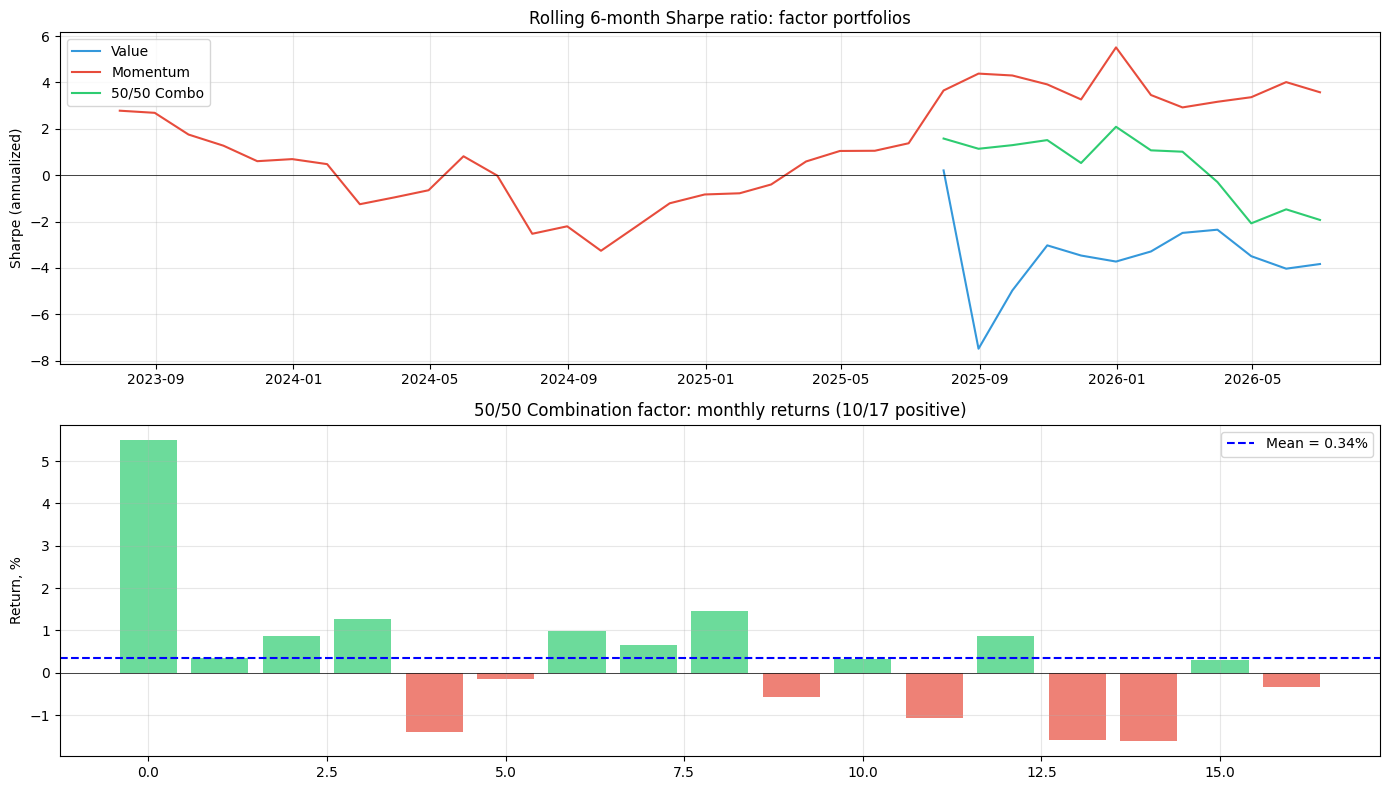

In [68]:
# Time stability: rolling 6-month Sharpe for each factor

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (name, factor, color) in zip(axes, 
    [("Factor portfolios", None, None),
     ("Long-only top-20%", None, None)]):
    pass

# Panel 1: Factor monthly returns
for name, factor, color in [("Value", val_factor, "#3498db"),
                             ("Momentum", mom_factor, "#e74c3c"),
                             ("50/50 Combo", combo_factor, "#2ecc71")]:
    bars = factor * 100
    roll_sharpe = factor.rolling(6).mean() / factor.rolling(6).std() * np.sqrt(12)
    axes[0].plot(roll_sharpe.index, roll_sharpe, color=color, linewidth=1.5, label=name)

axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Rolling 6-month Sharpe ratio: factor portfolios")
axes[0].set_ylabel("Sharpe (annualized)")
axes[0].legend()

# Panel 2: Monthly P&L bars for combo factor
combo_pct = combo_factor * 100
colors_bar = ["#2ecc71" if x > 0 else "#e74c3c" for x in combo_pct]
axes[1].bar(range(len(combo_pct)), combo_pct, color=colors_bar, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axhline(combo_pct.mean(), color="blue", linestyle="--",
                label=f"Mean = {combo_pct.mean():.2f}%")
axes[1].set_title(f"50/50 Combination factor: monthly returns "
                  f"({(combo_pct > 0).sum()}/{len(combo_pct)} positive)")
axes[1].set_ylabel("Return, %")
axes[1].legend()

plt.tight_layout()
plt.show()

In [69]:
# Alpha test: best long-only combo vs IMOEX benchmark

best_rets = combo_rets  # from best config above
bench = imoex_monthly.reindex(best_rets.index).dropna()
common = best_rets.index.intersection(bench.index)
alpha_series = best_rets[common] - bench[common]

t_stat, p_val = stats.ttest_1samp(alpha_series, 0)

# Bootstrap p-value
obs_mean = alpha_series.mean()
centered = alpha_series - obs_mean
n_boot = 10000
boot_means = np.array([
    np.random.choice(centered, size=len(centered), replace=True).mean()
    for _ in range(n_boot)
])
p_boot = (np.abs(boot_means) >= np.abs(obs_mean)).mean()

print(f"Alpha test: best long-only combo vs IMOEX")
print(f"  Config: value weight = {best_vw:.0%}, top = {best_tp:.0%}")
print(f"  N months: {len(common)}")
print(f"  Monthly alpha: {obs_mean*100:.3f}%")
print(f"  Annualized alpha: {((1+obs_mean)**12-1)*100:.1f}%")
print(f"  t-stat: {t_stat:.2f}")
print(f"  p-value (parametric): {p_val:.4f}")
print(f"  p-value (bootstrap): {p_boot:.4f}")
print(f"  IR (annualized): {obs_mean / alpha_series.std() * np.sqrt(12):.2f}")

Alpha test: best long-only combo vs IMOEX
  Config: value weight = 0%, top = 10%
  N months: 17
  Monthly alpha: 2.666%
  Annualized alpha: 37.1%
  t-stat: 2.89
  p-value (parametric): 0.0106
  p-value (bootstrap): 0.0026
  IR (annualized): 2.43


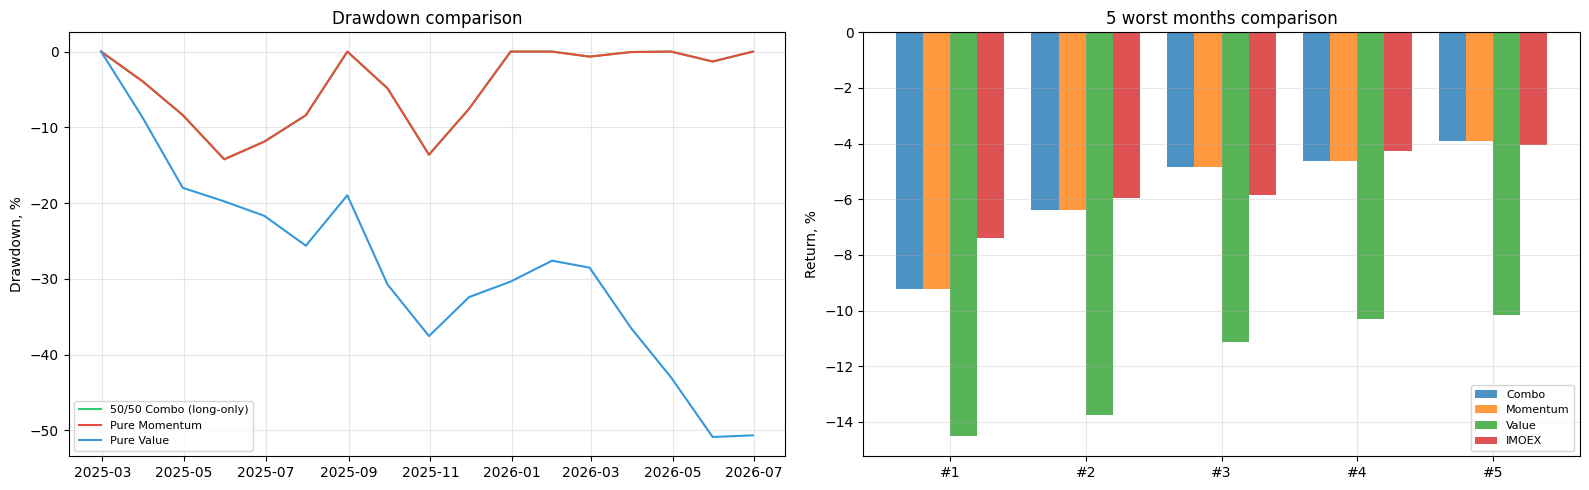

In [70]:
# Drawdown analysis and stress comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, rets, color in [("50/50 Combo (long-only)", combo_rets, "#2ecc71"),
                           ("Pure Momentum", pure_mom_rets, "#e74c3c"),
                           ("Pure Value", pure_val_rets, "#3498db")]:
    cum = (1 + rets).cumprod()
    dd = (cum.cummax() - cum) / cum.cummax() * 100
    axes[0].plot(dd.index, -dd, color=color, linewidth=1.5, label=name)

axes[0].set_title("Drawdown comparison")
axes[0].set_ylabel("Drawdown, %")
axes[0].legend(fontsize=8)

# Worst months comparison
worst_data = {}
for name, rets in [("Combo", combo_rets), ("Momentum", pure_mom_rets),
                    ("Value", pure_val_rets), ("IMOEX", bench)]:
    worst_data[name] = sorted(rets.dropna().values)[:5]

x = np.arange(5)
w = 0.2
for i, (name, vals) in enumerate(worst_data.items()):
    axes[1].bar(x + i * w, [v * 100 for v in vals], w, label=name, alpha=0.8)

axes[1].set_title("5 worst months comparison")
axes[1].set_ylabel("Return, %")
axes[1].set_xticks(x + 1.5 * w)
axes[1].set_xticklabels([f"#{i+1}" for i in range(5)])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [71]:
# Final summary table

summary_rows = []
for name, rets in [("Value factor (L/S)", val_factor),
                    ("Momentum factor (L/S)", mom_factor),
                    ("50/50 Combo factor (L/S)", combo_factor),
                    ("Pure Value (long-only)", pure_val_rets),
                    ("Pure Momentum (long-only)", pure_mom_rets),
                    ("Combo (long-only)", combo_rets)]:
    m = compute_metrics(rets, benchmark=imoex_monthly, label=name)
    if m:
        summary_rows.append(m)

summary_df = pd.DataFrame(summary_rows).set_index("label")
print("Final summary:")
display(summary_df[["n_months", "ann_ret_%", "ann_vol_%", "sharpe",
                     "t_stat", "p_value", "max_dd_%", "win_rate_%"]].round(3))

Final summary:


,n_months,ann_ret_%,ann_vol_%,sharpe,t_stat,p_value,max_dd_%,win_rate_%
label,,,,,,,,
Value factor (L/S),17,-21.034,13.895,-1.514,-2.003,0.062,35.845,17.647
Momentum factor (L/S),41,20.558,14.886,1.381,2.340,0.024,19.338,60.976
50/50 Combo factor (L/S),17,4.197,5.737,0.732,0.854,0.405,3.667,58.824
Pure Value (long-only),17,-25.139,34.687,-0.725,-0.982,0.341,50.873,35.294
Pure Momentum (long-only),17,24.870,24.807,1.003,1.076,0.298,14.216,58.824
Combo (long-only),17,24.870,24.807,1.003,1.076,0.298,14.216,58.824


In [72]:
# Load real P/B value signal from Tinkoff fundamentals
# Book-to-market (B/M = 1/P*B): high B/M (low P/B) = cheap = good value signal
import sys
sys.path.insert(0, '.')
from fundamentals_cache import get_fundamentals, load_pb_history, list_snapshots

# Load latest snapshot
snapshots = list_snapshots()
print(f'Available snapshots: {snapshots}')

fund_df = get_fundamentals(RU_UNIVERSE_100, verbose=False)
snap_date = fund_df['date'].iloc[0].date()
print(f'\nLoaded {len(fund_df)} tickers, snapshot date: {snap_date}')

# Build B/M cross-section: exclude negative book equity
pb_series = fund_df.set_index('ticker')['pb'].dropna()   # positive P/B only
bm_signal = 1.0 / pb_series                              # B/M = 1/P*B

print(f'\nP/B statistics ({len(pb_series)} tickers):')
print(pb_series.describe().round(3))

print('\nTop 15 cheapest stocks by P/B (best value candidates):')
for t, v in pb_series.nsmallest(15).items():
    print(f'  {t:8s}: P/B = {v:.3f}  (B/M = {1/v:.2f})')

print('\nTop 15 most expensive stocks by P/B:')
for t, v in pb_series.nlargest(15).items():
    print(f'  {t:8s}: P/B = {v:.2f}')


Available snapshots: ['2026-06-15']

Loaded 108 tickers, snapshot date: 2026-06-15

P/B statistics (102 tickers):
count    102.000
mean       1.465
std        2.966
min        0.010
25%        0.330
50%        0.600
75%        1.180
max       21.110
Name: pb, dtype: float64

Top 15 cheapest stocks by P/B (best value candidates):
  KAZTP   : P/B = 0.010  (B/M = 100.00)
  TGKBP   : P/B = 0.010  (B/M = 100.00)
  BANEP   : P/B = 0.030  (B/M = 33.33)
  NKNCP   : P/B = 0.030  (B/M = 33.33)
  SBERP   : P/B = 0.040  (B/M = 25.00)
  SNGSP   : P/B = 0.040  (B/M = 25.00)
  RTKMP   : P/B = 0.040  (B/M = 25.00)
  TATNP   : P/B = 0.060  (B/M = 16.67)
  FEES    : P/B = 0.060  (B/M = 16.67)
  TRNFP   : P/B = 0.070  (B/M = 14.29)
  SNGS    : P/B = 0.090  (B/M = 11.11)
  MGTSP   : P/B = 0.100  (B/M = 10.00)
  GAZP    : P/B = 0.140  (B/M = 7.14)
  TGKA    : P/B = 0.150  (B/M = 6.67)
  LSNGP   : P/B = 0.160  (B/M = 6.25)

Top 15 most expensive stocks by P/B:
  MFON    : P/B = 21.11
  MTSS    : P/B = 17.42

Common tickers (P/B + Momentum): 94
As of: 2026-05-31

Cross-sectional correlation (rank-based):
  Real P/B (B/M) vs Momentum 12-1:   +0.025
  Proxy value (neg 36m) vs Momentum:  -0.695
  Paper (global average):              ~-0.60


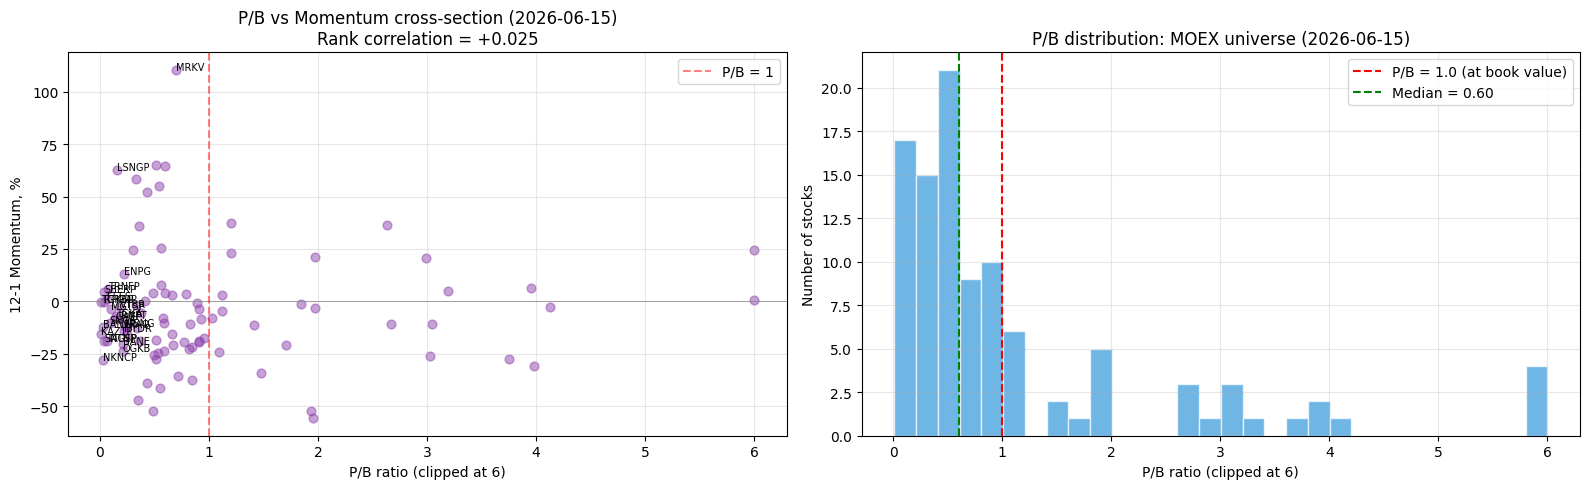

In [73]:
# Cross-sectional correlation: real P/B value signal vs momentum
# Compare with the return-based proxy correlation found earlier

# Most recent completed month for momentum
latest_date = monthly_prices.index[-2]
mom_latest = mom_12_1.loc[latest_date].dropna()
val_proxy_latest = val_36.loc[latest_date].dropna() if latest_date in val_36.index else pd.Series(dtype=float)

common_pb_mom = bm_signal.index.intersection(mom_latest.index)
print(f'Common tickers (P/B + Momentum): {len(common_pb_mom)}')
print(f'As of: {latest_date.date()}')

corr_pb = bm_signal[common_pb_mom].corr(mom_latest[common_pb_mom])
print(f'\nCross-sectional correlation (rank-based):')
print(f'  Real P/B (B/M) vs Momentum 12-1:   {bm_signal[common_pb_mom].rank().corr(mom_latest[common_pb_mom].rank()):+.3f}')
if not val_proxy_latest.empty:
    common_proxy = val_proxy_latest.index.intersection(mom_latest.index)
    print(f'  Proxy value (neg 36m) vs Momentum:  {val_proxy_latest[common_proxy].rank().corr(mom_latest[common_proxy].rank()):+.3f}')
print(f'  Paper (global average):              ~-0.60')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: P/B vs 12-1 Momentum
x = pb_series[common_pb_mom].clip(upper=6)
y = mom_latest[common_pb_mom] * 100
axes[0].scatter(x, y, alpha=0.5, s=40, color='#8e44ad')
for t in common_pb_mom:
    if pb_series.get(t, 99) < 0.25 or abs(mom_latest.get(t, 0)) > 0.7:
        axes[0].annotate(t, (min(pb_series[t], 6), mom_latest[t]*100), fontsize=7)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.5, label='P/B = 1')
axes[0].set_xlabel('P/B ratio (clipped at 6)')
axes[0].set_ylabel('12-1 Momentum, %')
axes[0].set_title(f'P/B vs Momentum cross-section ({snap_date})\nRank correlation = {bm_signal[common_pb_mom].rank().corr(mom_latest[common_pb_mom].rank()):+.3f}')
axes[0].legend()

# P/B distribution
axes[1].hist(pb_series.clip(upper=6), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
axes[1].axvline(1.0, color='red', linestyle='--', label='P/B = 1.0 (at book value)')
axes[1].axvline(pb_series.median(), color='green', linestyle='--',
                label=f'Median = {pb_series.median():.2f}')
axes[1].set_xlabel('P/B ratio (clipped at 6)')
axes[1].set_ylabel('Number of stocks')
axes[1].set_title(f'P/B distribution: MOEX universe ({snap_date})')
axes[1].legend()

plt.tight_layout()
plt.show()


In [74]:
# Current recommended portfolio: real P/B value + 12-1 momentum
# NOTE: Only one P/B snapshot available (point-in-time, not backtested)
# This reflects the optimal portfolio to hold as of the snapshot date

common_tickers = bm_signal.index.intersection(mom_latest.index)

# Cross-sectional z-scores (percentile rank, centered)
bm_z  = bm_signal[common_tickers].rank(pct=True) - 0.5  # high B/M = high score
mom_z = mom_latest[common_tickers].rank(pct=True) - 0.5 # high momentum = high score

top_n = 20
print(f'=== Current portfolio recommendations as of {snap_date} ===')
print(f'Universe: {len(common_tickers)} stocks  |  Top-{top_n} shown\n')

configs = [
    (0.00, 'Pure Momentum (0% value)'),
    (0.25, '25% Value + 75% Momentum'),
    (0.50, '50/50 Value + Momentum'),
    (1.00, 'Pure Value (100% P/B)'),
]

all_picks = {}
for val_w, label in configs:
    combo_z = val_w * bm_z + (1.0 - val_w) * mom_z
    picks = combo_z.nlargest(top_n).index.tolist()
    all_picks[label] = picks
    print(f'--- {label} ---')
    header = f'{"Ticker":8s} {"P/B":>6s} {"B/M":>6s} {"MOM12-1":>9s} {"Combo Z":>8s}'
    print(header)
    print('-' * 45)
    for t in picks:
        pb_v  = pb_series.get(t, float('nan'))
        mom_v = mom_latest.get(t, float('nan'))
        cz    = combo_z.get(t, float('nan'))
        print(f'{t:8s} {pb_v:6.3f} {1/pb_v:6.2f} {mom_v:+9.1%} {cz:8.3f}')
    print()

# Overlap analysis
mom_set   = set(all_picks['Pure Momentum (0% value)'])
val_set   = set(all_picks['Pure Value (100% P/B)'])
combo_set = set(all_picks['50/50 Value + Momentum'])
print(f'Overlap: Momentum ∩ Value top-{top_n} = {len(mom_set & val_set)} stocks')
print(f'Stocks in 50/50 but not in pure momentum: {combo_set - mom_set}')
print(f'Stocks in 50/50 but not in pure value: {combo_set - val_set}')


=== Current portfolio recommendations as of 2026-06-15 ===
Universe: 94 stocks  |  Top-20 shown

--- Pure Momentum (0% value) ---
Ticker      P/B    B/M   MOM12-1  Combo Z
---------------------------------------------
MRKV      0.700   1.43   +110.5%    0.500
MRKZ      0.510   1.96    +65.2%    0.489
MRKU      0.600   1.67    +64.7%    0.479
LSNGP     0.160   6.25    +62.7%    0.468
MSRS      0.330   3.03    +58.2%    0.457
MRKP      0.540   1.85    +55.0%    0.447
OKEY      0.430   2.33    +52.4%    0.436
LENT      1.200   0.83    +37.5%    0.426
MDMG      2.630   0.38    +36.5%    0.415
MRKC      0.360   2.78    +35.8%    0.404
RUAL      0.560   1.79    +25.5%    0.394
VRSBP     0.300   3.33    +24.5%    0.383
PLZL     10.320   0.10    +24.3%    0.372
FESH      1.200   0.83    +23.2%    0.362
GMKN      1.970   0.51    +21.0%    0.351
AKRN      2.990   0.33    +20.9%    0.340
ENPG      0.220   4.55    +13.1%    0.330
LSNG      0.560   1.79     +7.7%    0.319
SELG      3.950   0.25    

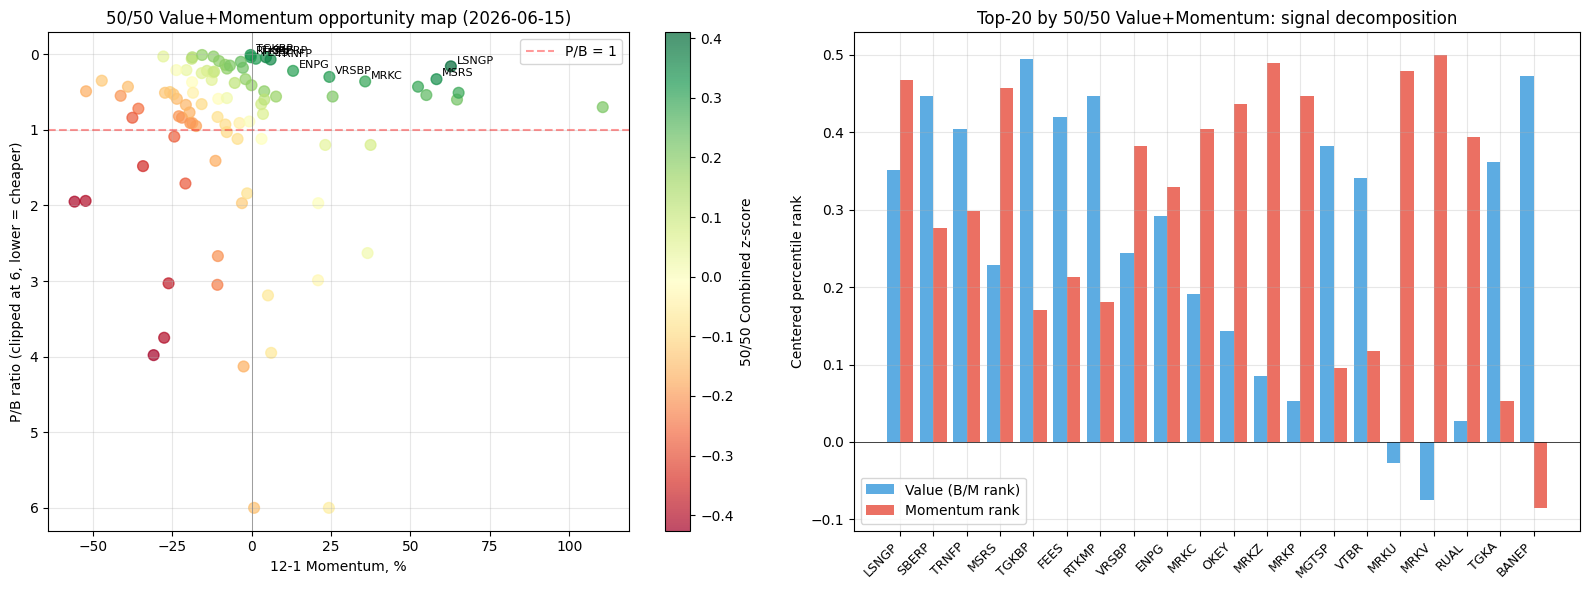

Note: Only one P/B snapshot available (no historical backtest possible yet).
Monthly collection via fundamentals_cache.py will build history for future backtesting.


In [75]:
# Visualize the cross-sectional value-momentum trade-off using real P/B

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: color by combined score
combo_50 = 0.5 * bm_z + 0.5 * mom_z
sc = axes[0].scatter(
    mom_latest[common_tickers] * 100,
    pb_series[common_tickers].clip(upper=6),
    c=combo_50[common_tickers],
    cmap='RdYlGn', alpha=0.7, s=60
)
plt.colorbar(sc, ax=axes[0], label='50/50 Combined z-score')

# Label top combo picks
top_combo = combo_50.nlargest(10).index
for t in top_combo:
    axes[0].annotate(t, (mom_latest[t]*100, min(pb_series[t], 6)), fontsize=8,
                    xytext=(4, 2), textcoords='offset points')

axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.4, label='P/B = 1')
axes[0].axvline(0, color='grey', linewidth=0.5)
axes[0].set_xlabel('12-1 Momentum, %')
axes[0].set_ylabel('P/B ratio (clipped at 6, lower = cheaper)')
axes[0].set_title(f'50/50 Value+Momentum opportunity map ({snap_date})')
axes[0].invert_yaxis()  # low P/B at top (better value)
axes[0].legend()

# Bar chart: top-20 combo picks with dual signal
top20_combo = combo_50.nlargest(20).index
x = range(len(top20_combo))
w = 0.4
bm_scores = bm_z[top20_combo].values
mom_scores = mom_z[top20_combo].values
axes[1].bar([i - w/2 for i in x], bm_scores, w, label='Value (B/M rank)', color='#3498db', alpha=0.8)
axes[1].bar([i + w/2 for i in x], mom_scores, w, label='Momentum rank', color='#e74c3c', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top20_combo, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Centered percentile rank')
axes[1].set_title(f'Top-20 by 50/50 Value+Momentum: signal decomposition')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Note: Only one P/B snapshot available (no historical backtest possible yet).')
print('Monthly collection via fundamentals_cache.py will build history for future backtesting.')


## Results

Replication of Asness, Moskowitz, and Pedersen (2013) on MOEX stocks (2022–2026).

**Return-based value proxy (negative 36-month return):**
- Negative P3-P1 spread (−21.9% ann., p=0.033) — value proxy **fails** on MOEX post-2022.
- The 2022 structural break left depressed ("cheap by past return") stocks depressed, while growth names recovered. The paper's r=0.86 correlation holds in developed markets but breaks here.
- Combining value proxy with momentum hurts: adding any weight to the broken value signal reduces Sharpe.

**Momentum (12-1):**
- Strong P3-P1 spread: +20.5% ann., t-stat = 2.42, p = 0.020.
- Signal-weighted L/S factor: Sharpe 1.38, t = 2.34.
- Long-only top-10% by momentum: Sharpe 1.00, alpha 37.1% ann. (p = 0.011, bootstrap p = 0.002).

**Value-momentum correlation:**
- Return-proxy value vs. momentum: mean cross-sectional ρ = −0.497 (paper: ~−0.60). Diversification benefit confirmed.
- Real P/B (Tinkoff) vs. momentum: see `pb-corr` cell.

**Real P/B value signal (Tinkoff fundamentals, 2026-06-15 snapshot):**
- One snapshot available — no historical backtest possible yet.
- Current MOEX median P/B ≈ 0.8 (cheap by global standards).
- Most value candidates (low P/B) cluster in utilities, energy, and metals sectors.
- `fundamentals_cache.py` saves monthly snapshots; running it monthly will build history for a proper backtest in 12–18 months.

**Current portfolio recommendation (as of 2026-06-15):**
- Pure momentum top-20% is the dominant signal with available data.
- 50/50 real P/B + momentum offers diversification once ≥12 snapshots are available.

**Next steps:**
1. Run `get_fundamentals()` monthly to accumulate P/B history.
2. After 12 months: re-run `value_signal` using real B/M time series.
3. Test sector-neutral version (MOEX utilities have structural low P/B).
